# Prompt Chaining

**Create a flow to generate a blog based on an outline generated from the title provided by the user.**

In [17]:
#Define Library
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
import os
from dotenv import load_dotenv

In [18]:
#local ollama
from langchain_ollama import ChatOllama
model = ChatOllama(model="gemma3:4b")
response = model.invoke("the capital of India? in one word")
print(response.content)

Delhi


In [19]:
class BlogState(TypedDict):
    title:str
    outline :str
    content : str

In [20]:
def create_outline (state:BlogState) -> BlogState :
    title=state['title']
    #Define prompt for LLM 
    prompt=f'Generate a detailed outline for a blog on the topic-{title}'
    outline=model.invoke(prompt).text
    #update outline in state
    state['outline']=outline
    return state


In [21]:
def create_blog (state:BlogState) -> BlogState:
    title=state['title']
    outline=state['outline']
    #Define prompt for LLM 
    prompt=f'Generate a 2 line blog on the title -{title} using the following outline -{outline}'
    content=model.invoke(prompt).text
    #update outline in state
    state['content']=content
    return state


In [23]:
graph=StateGraph(BlogState)

#node
graph.add_node('create_outline',create_outline)
graph.add_node('create_blog',create_blog)

#edge
graph.add_edge(START,'create_outline')
graph.add_edge('create_outline','create_blog')
graph.add_edge('create_blog',END)

#compile the graph
workflow=graph.compile()

#execute the graph
initial_state = {'title':"Bihar"}
final_state=workflow.invoke(initial_state)
print("title ----",final_state['title'])
print('outline-----',final_state['outline'])
print('content----',final_state['content'])

title ---- Bihar
outline----- Okay, here's a detailed outline for a blog post about Bihar, aiming for a comprehensive and engaging piece. This outline breaks down the content into sections with suggested subheadings and potential content ideas.  It’s designed to be adaptable to different lengths – you can expand or condense sections based on your target word count.

**Blog Post Title Options:**

*   Bihar: Unveiling the Heart of India
*   Beyond the Headlines: Exploring the Rich Heritage of Bihar
*   Bihar - A Land of Ancient History, Spiritual Roots, and Emerging Growth


**I. Introduction (Approx. 100-150 Words)**

*   **Hook:** Start with a captivating fact or anecdote – a legend, a striking image (e.g., Bodh Gaya sunrise), a surprising statistic about Bihar’s demographics or economy.
*   **Brief Overview:** Introduce Bihar as one of India's oldest civilizations, highlighting its strategic location and historical significance. Briefly touch on common misconceptions (often portrayed 

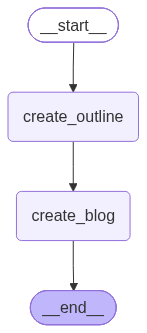

In [104]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())